 <h1 style="color : blue"> Aula03.3- ML- Regressão Linear Multipla (RLM) x RLS x DR </h1>

 <b> Regressão Linear Múltipla</b>: 
 
 Diferente da Regressão Simples (que usa apenas uma variável X para prever Y), a Múltipla utiliza vários fatores simultaneamente. É como tentar prever o preço de uma casa não apenas pelo tamanho, mas também pelo bairro, número de quartos e idade do imóvel.
 
É um algoritmo estatístico que modela a relação entre uma variável dependente (alvo) e duas ou mais variáveis independentes (preditores). Matematicamente, ela busca encontrar os melhores coeficientes ($\beta$) para a equação:

$$y = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_nx_n + \epsilon$$

 <h5 style="color : green">Onde </h5>
<ul>
    

<li> <b>$\beta_0$ </b> é a intersecção e </li>
<li> <b>$\epsilon$</b> é o erro residual.</li>
</ul>

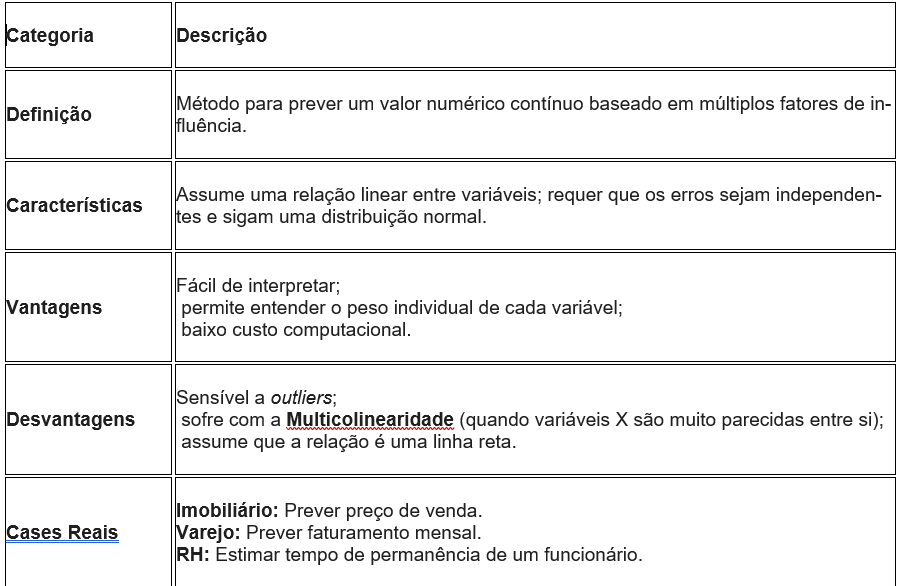

<h2 style="color : green">Exemplo </h2>

Considere um cenário em que você deve prever o preço da casa com base em sua área, número de quartos, renda média das pessoas na área, idade da casa e assim por diante. Nesse caso, a variável dependente (variável de destino) depende de várias variáveis independentes.

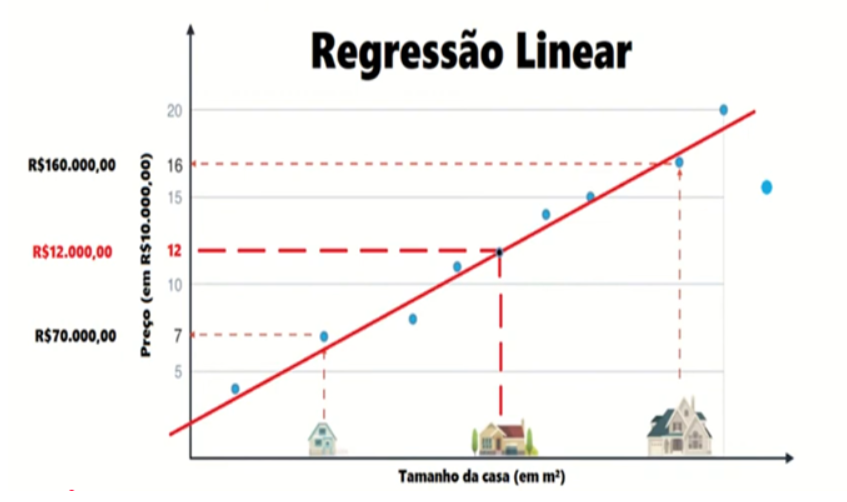

Métricas de Avaliação: Como saber se o modelo é bom?
Para avaliar se o seu modelo de Regressão Múltipla está "acertando" ou apenas "chutando", você deve observar estas métricas principais:
<pre>
<b> 1. R-Quadrado (R^2)</b>: Coeficiente de Determinação
    •	O que diz: Quanto da variação dos dados o seu modelo explica.
    •	Escala: 0 a 1 (ou 0% a 100%).
    •	Interpretação: Um R^2 de 0.85 significa que 85% do faturamento é explicado pelas variáveis que você escolheu.
<b>2. R-Quadrado Ajustado (Adjusted R^2)</b>
    •	Por que usar: Na Regressão Múltipla, se você adicionar colunas inúteis, o R^2 normal sobe fal-samente. 
        O Ajustado penaliza a inclusão de variáveis que não ajudam o modelo. É a métrica mais honesta para modelos com muitas variáveis.
<b>3. MAE (Mean Absolute Error)</b>:
    •	O que diz: O erro médio em valores absolutos (ex: reais).
    •	Interpretação: Se o MAE é R$ 50,00, seu modelo erra, em média, 50 reais para cima ou para bai-xo.
<b>4. RMSE (Root Mean Square Error)</b>:
    •	O que diz: A raiz do erro quadrático médio.
    •	Interpretação: Diferente do MAE, o RMSE penaliza erros grandes com mais força. É ideal se vo-cê quer evitar "erros grotescos" na sua previsão.
</pre>

 Dica do Professor: O Perigo da Multicolinearidade
Ao usar muitas variáveis (como fizemos com o One-Hot Encoding), certifique-se no seu Heatmap de que as variáveis preditoras não são muito correlacionadas entre si. 


<ul> 
<li> <b>Passo 1: Instalação das Bibliotecas </b>: Primeiro, você precisa ter as bibliotecas necessárias instaladas. Caso ainda não tenha, você pode instalá-las usando o pip:</li>
        <pre>
            <i>pip install pandas scikit-learn matplotlib </i>
        </pre>

<li> <b>Passo 2: Importando as Bibliotecas </b>:Inicie seu script importando as bibliotecas necessárias:</li>
    <pre> <i>
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.model_selection import train_test_split
    from sklearn.linear_model import LinearRegression
    </pre>

<li> <b>Passo 3: Criar DataFrame </b></li>
<li> <b>Passo 4: Dividindo os Dados em Conjuntos de Treinamento (70 %) e Teste (30%)</b>. É importante dividir os dados em conjuntos de treinamento e teste para avaliar o desempenho do modelo.</li>
    <pre> 
     <i>X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)</i>
    </pre>
    
<li> <b> Passo 5: Criando e Ajustando o Modelo de RLM, RLS, DR</b></li>
<li> <b> Passo 6: Fazendo Previsões: Usaremos o modelo treinado para fazer previsões com os dados de teste.</b></li>
<li> <b> Passo 7: Metricas de avaliação: </b>Podemos avaliar o modelo utilizando métricas como o coeficiente de determinação \(MAE, R^2 \).</li>
<li> <b> Passo 8: Visualizando os Resultados:</b>Vamos plotar os dados e a linha de regressão. </li>
</ul>

In [34]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [5]:
np.random.seed(42)
n = 1000
investimento = np.random.normal(100, 20, n)
vendedores = np.random.normal(10, 3, n)

# O retorno depende de ambos + um pouco de ruído
retorno = (2.5 * investimento) + (15 * vendedores) + np.random.normal(0, 15, n)

roi_df = pd.DataFrame({
    'Investimento': investimento,
    'Vendedores': vendedores,
    'Retorno': retorno
})

roi_df

,Investimento,Vendedores,Retorno
0,109.934283,14.198066,477.679028
1,97.234714,12.773901,432.527521
2,112.953771,10.178891,423.181495
3,130.460597,8.059190,442.419915
4,95.316933,12.094670,391.308160
...,...,...,...
995,94.377994,13.210451,435.263954
996,135.953731,9.920436,492.557158
997,112.816857,7.354376,373.731375
998,88.576420,9.510799,369.115683


In [7]:
roi_df.shape

(1000, 3)

In [8]:
roi_df.describe()

,Investimento,Vendedores,Retorno
count,1000.000000,1000.000000,1000.000000
mean,100.386641,10.212509,404.241747
std,19.584319,2.992363,66.850922
min,35.174653,1.178834,205.486770
25%,87.048194,8.181275,362.826838
50%,100.506012,10.189231,402.980144
75%,112.958878,12.186647,446.834239
max,177.054630,19.579323,671.356899


In [9]:
roi_df.head()

,Investimento,Vendedores,Retorno
0,109.934283,14.198066,477.679028
1,97.234714,12.773901,432.527521
2,112.953771,10.178891,423.181495
3,130.460597,8.059190,442.419915
4,95.316933,12.094670,391.308160


<h2 style="color : green"> Coeficiente de Person (r)</h2>

O Coeficiente de Pearson e o P-valor (fator p) são o "coração" e a "consciência" estatística.
Eles nos ajudam a responder duas perguntas cruciais antes de gastarmos tempo treinando modelos complexos:
<ol>
<li> <b> Pearson</b>: Existe uma relação entre essas variáveis? Ela é forte?</li>
<li> <b> P-valor</b>: Essa relação é real ou foi apenas um golpe de sorte (acaso)?</li>
</ol>

<h4 style="color : green"> a) Coeficiente de Correlação de Pearson (r) </h4>
O coeficiente de Pearson mede a força e a direção da relação linear entre duas variáveis.
<ul>
<li> <b>Positivo (+)</b>: Quando X sobe, Y sobe.</li>
<li> <b> Negativo (-)</b>: Quando X sobe, Y desce.</li>
<li> <b> Zero (0)</b>: Não há relação linear (uma nuvem de pontos sem sentido).
</ul>

<h4 style="color : green"> b) O P-valor (Fator p)</h4>
O p-valor é a probabilidade de os resultados observados terem ocorrido por puro acaso. Na ciência de dados, usamos ele para testar a nossa Hipótese Nula (H0: "Não há relação entre as variáveis").

<ol>
<li> <b>P-valor baixo (≤ 0.05)</b>: "Rejeitamos o acaso". A relação é estatisticamente significante.</li>
<li> <b>P-valor alto (> 0.05)</b>: "Pode ser sorte". Não temos evidências de que a relação seja real</li>
</ul>

In [39]:
r = pearsonr(roi_df["Investimento"], roi_df["Retorno"])
print('Coeficiente de correlação =',r)

print("Coeficiente de correlação = ")
roi_df.corr()

Coeficiente de correlação = PearsonRResult(statistic=np.float64(0.710145353528309), pvalue=np.float64(2.8968454483443852e-154))
Coeficiente de correlação = 


,Investimento,Vendedores,Retorno
Investimento,1.000000,-0.040400,0.710145
Vendedores,-0.040400,1.000000,0.639366
Retorno,0.710145,0.639366,1.000000


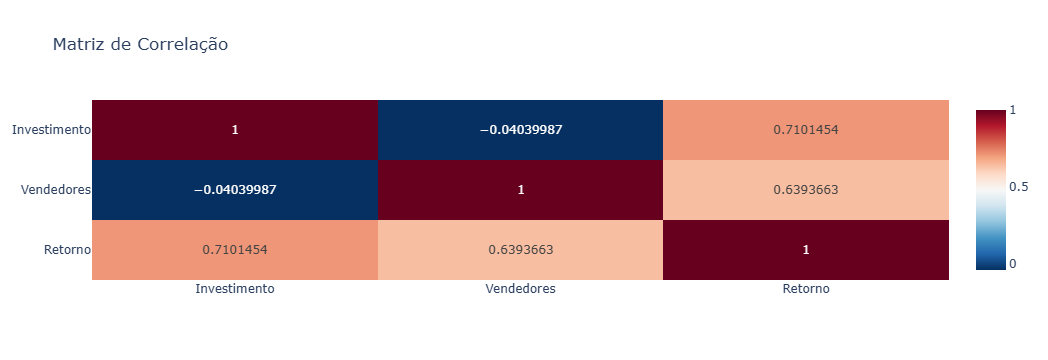

In [40]:
#Calcular a matriz de correlação


corr_matrix = roi_df.corr()

# 3. Criar o mapa de calor interativo com Plotly Express
fig = px.imshow(
    corr_matrix,
    text_auto=True,  # Exibe os valores dentro dos quadrados
    color_continuous_scale='RdBu_r',  # Escala de cores (vermelho/azul)
    aspect="auto",
    title="Matriz de Correlação"
)

# 4. Exibir o gráfico no Jupyter
fig.show()

In [13]:
# 2. Preparando os Modelos
# X_simples usa apenas Investimento | X_multi usa ambos

X_simples = roi_df[['Investimento']]
X_multi = roi_df[['Investimento', 'Vendedores']]
y = roi_df['Retorno']

# Split para a Regressão Simples
X_train_rls, X_test_rls, y_train_rls, y_test_rls  = train_test_split(X_simples, y, test_size=0.3, random_state=42)

print( "X_train_rls =", X_train_rls.shape)
print( "y_train_rls =", y_train_rls.shape)
print("")
print("X_test_rls =", X_test_rls.shape)
print("y_test_rls = ",  y_test_rls.shape)



X_train_rls = (700, 1)
y_train_rls = (700,)

X_test_rls = (300, 1)
y_test_rls =  (300,)


In [14]:
# Split para a Regressão Múltipla
X_train_rlm, X_test_rlm, y_train_rlm, y_test_rlm = train_test_split(X_multi, y, test_size=0.3, random_state=42)

print( "X_train_rlm =", X_train_rlm.shape)
print( "y_train_rlm =", y_train_rlm.shape)
print("")
print("X_test_rlm =", X_test_rlm.shape)
print("y_test_rlm = ",  y_test_rlm.shape)

X_train_rlm = (700, 2)
y_train_rlm = (700,)

X_test_rlm = (300, 2)
y_test_rlm =  (300,)


In [ ]:
X_train_rls = (700, 1)
y_train_rls = (700,)

X_test_rls = (300, 1)
y_test_rls =  (300,)

In [ ]:
# Criando o modelo
model_dr = DummyRegressor(strategy='mean')
model_rls = LinearRegression()
model_rlm = LinearRegression()


# Treinando os 3 modelos
model_dr.fit(X_train_rls[['Investimento']], y_train_rls)
model_rls.fit(X_train_rls[['Investimento']], y_train_rls) # Só usa 1 coluna
model_rlm.fit(X_train_rlm, y_train_rlm) # Usa todas as colunas

In [20]:
# Treinando os 3 modelos
model_dr = DummyRegressor(strategy='mean').fit(X_train_rls[['Investimento']], y_train_rls)
model_rls = LinearRegression().fit(X_train_rls[['Investimento']], y_train_rls) # Só usa 1 coluna
model_rlm = LinearRegression().fit(X_train_rlm, y_train_rlm) # Usa todas as colunas

In [21]:
# 3. Previsões
y_pred_dr = model_dr.predict(X_test_rls)
y_pred_rls = model_rls.predict(X_test_rls[['Investimento']])
y_pred_rlm = model_rlm.predict(X_test_rlm)


print("y_pred_dr =", y_pred_dr.shape)
print("y_pred_rls =", y_pred_rls.shape)
print("y_pred_rlm= ",  y_pred_rlm.shape)

y_pred_dr = (300,)
y_pred_rls = (300,)
y_pred_rlm=  (300,)


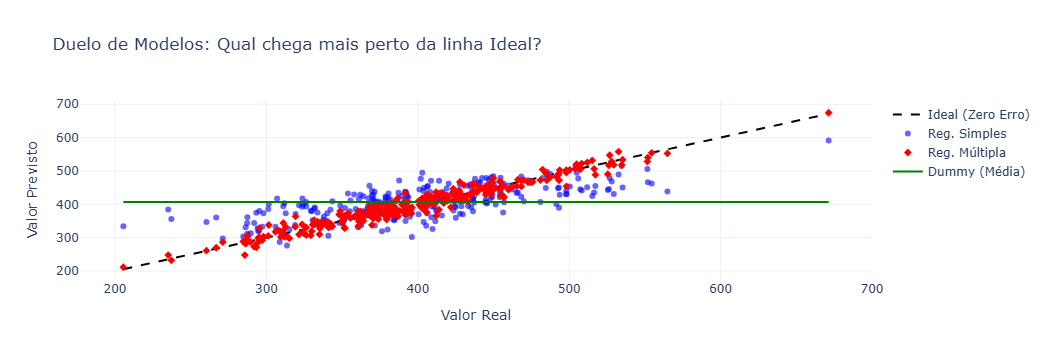

In [23]:
# 5. Visualização Dinâmica com Plotly (Comparando Erros Residuais)
# Como temos 2 variáveis X, o melhor jeito de ver a melhora é comparar o Erro Real vs Previsto
resumo = pd.DataFrame({
    'Real': y_test_rls,
    'Simples': y_pred_rls,
    'Multipla': y_pred_rlm,
    'Dummy': y_pred_dr
}).sort_values(by='Real')

fig = go.Figure()

# Adicionando Linha de Perfeição (Onde o erro seria zero)
fig.add_trace(go.Scatter(x=resumo['Real'], y=resumo['Real'], name='Ideal (Zero Erro)', line=dict(color='black', dash='dash')))

# Adicionando previsões
fig.add_trace(go.Scatter(x=resumo['Real'], y=resumo['Simples'], mode='markers', name='Reg. Simples', marker=dict(color='blue', opacity=0.6)))
fig.add_trace(go.Scatter(x=resumo['Real'], y=resumo['Multipla'], mode='markers', name='Reg. Múltipla', marker=dict(color='red', symbol='diamond')))
fig.add_trace(go.Scatter(x=resumo['Real'], y=resumo['Dummy'], mode='lines', name='Dummy (Média)', line=dict(color='green')))

fig.update_layout(title='Duelo de Modelos: Qual chega mais perto da linha Ideal?',
                  xaxis_title='Valor Real', yaxis_title='Valor Previsto',
                  template='plotly_white')
fig.show()

<h2 style="color : green"> Métricas de Avaliação</h2>

Como sabemos se a nossa "reta" é boa? Usamos métricas que medem a distância entre o ponto real e a previsão da reta.


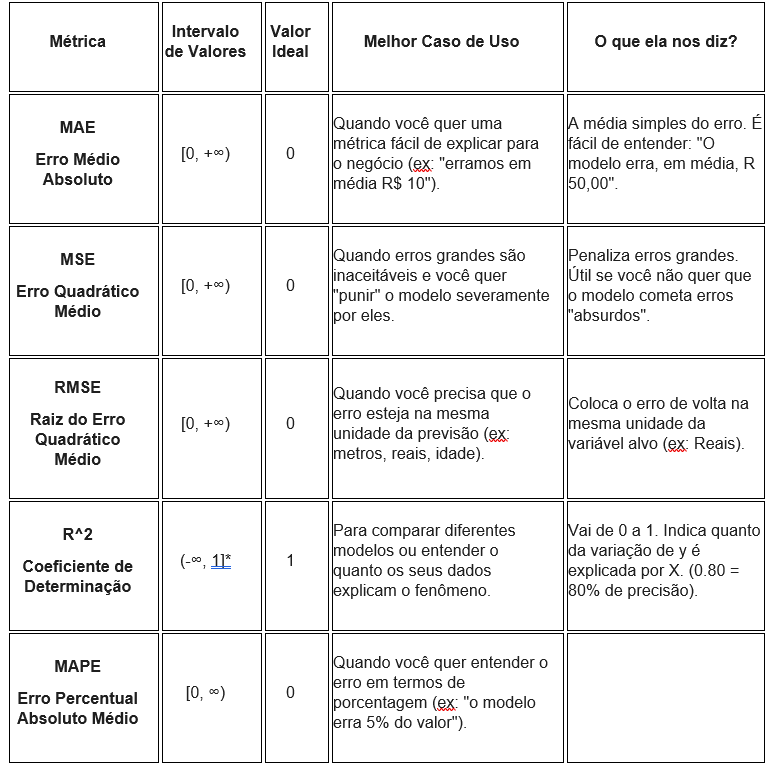



<h2 style="color : green">Ainteratividade ensina três conceitos que o gráfico estático esconde</h2>

<ul> 
<li> <b>Exploração de Resíduos</b>: No Plotly, você pode dar zoom em um ponto que está muito longe da linha vermelha e verificar as coordenadas exatas dele. Isso ajuda a entender o que é o Erro (Residual). </li>

<li> <b>Comparação Local</b>: Você pode desativar uma das linhas clicando na legenda. Tente desativar a "Regressão Linear" para ver como o Dummy parece perdido sem a inclinação.</li>

<li> <b>Identificação de Outliers</b>: Se houvesse um ponto muito fora da curva, você poderia configurar o hover_data para mostrar o ID do registro, facilitando a limpeza dos dados.</li>
</ul>

<h2 style="color : green">Conclusão </h2>

<ul> 
<li> <b>Nesta aula</b>, passamos pela teoria, pelas métricas e agora pela visualização avançada. Lembrem-se:

<li> <b>A Regressão Linear </b>tenta "explicar" a variabilidade.</li>


<li> <b>O Plotly</b> nos permite "enxergar" a qualidade dessa explicação.</li>

</ul>


In [35]:
# 4. Criando Tabela de Resultados no Console
print("R2 Dummy Regressor = ",  r2_score(y_test_rls, y_pred_dr))
print("MAE Dummy Regressor =", mean_absolute_error(y_test_rls,y_pred_dr))
print("RMSE Dummy Regressor =", np.sqrt(mean_squared_error(y_test_rls, y_pred_dr)))
print("R² Dummy Regressor  =", r2_score(y_test_rls, y_pred_dr))
print("")
print("")
print("R2 RL Simples = ", r2_score(y_test_rls, y_pred_rls))
print("MAE RL Simples = ", mean_absolute_error(y_test_rls, y_pred_rls))
print("RMSE RL Simples =", np.sqrt(mean_squared_error(y_test_rls, y_pred_rls)))
print("R² RL Simples =", r2_score(y_test_rls, y_pred_rls))
print("")
print("")
print("R2 RL Múltipla = ", r2_score(y_test_rlm, y_pred_rlm))
print("MAE RL Múltipla  = ", mean_absolute_error(y_test_rlm, y_pred_rlm))
print("RMSE RL Múltipla  =", np.sqrt(mean_squared_error(y_test_rlm, y_pred_rlm)))
print("R² RL Múltipla  =", r2_score(y_test_rlm, y_pred_rlm))

R2 Dummy Regressor =  -0.013864790913133085
MAE Dummy Regressor = 51.81248359779401
RMSE Dummy Regressor = 66.30668960329345
R² Dummy Regressor  = -0.013864790913133085


R2 RL Simples =  0.5106529196890872
MAE RL Simples =  36.36134909937067
RMSE RL Simples = 46.06550389614386
R² RL Simples = 0.5106529196890872


R2 RL Múltipla =  0.9465162410328095
MAE RL Múltipla  =  12.073517141741725
RMSE RL Múltipla  = 15.229241964805984
R² RL Múltipla  = 0.9465162410328095


<h2 style="color : green"> Tabela Comparativa de Performance</h2>

Validação de Modelos, e os números nos contam uma história muito clara sobre a complexidade do fenômeno que estamos estudando.

Para decidir qual modelo é o melhor, não olhamos apenas para um número, mas para o conjunto da obra. Vamos à análise técnica e acadêmica.



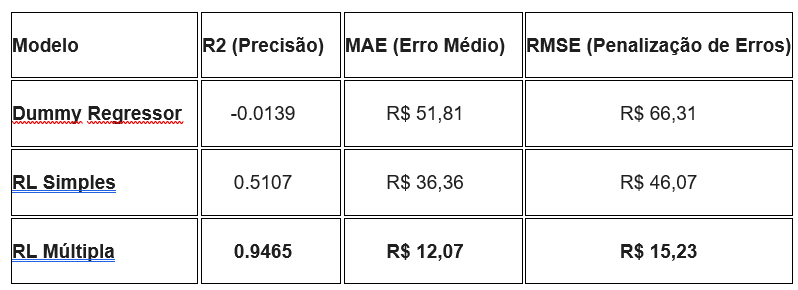
<h2 style="color : green"> Análise Crítica das Métricas</h2>

<h5 style="color : green"> (1) O Coeficiente de Determinação (R^2)</h5>

O R^2 mede a proporção da variância da variável dependente que é explicada pelo modelo.

•	Dummy (-0.0139): Um $R^2$ negativo indica que o modelo é pior do que simplesmente usar a média de todos os valores. Ele não aprendeu nada.

•	Simples (0.5107): Explica cerca de 51% da variação. É um modelo "médio", provavelmente usan-do apenas uma variável (como idade), deixando muita informação de fora.

•	Múltipla (0.9465): Explica 94,6% da variância. Isso indica um ajuste quase excelente aos dados.

<h5 style="color : green"> (2) MAE vs. RMSE </h5>
O MAE nos dá a média do erro, enquanto o RMSE penaliza erros maiores (devido ao quadrado na fórmula).

•	Na RL Múltipla, o MAE (12.07) e o RMSE (15.23) estão muito próximos. Academicamente, isso sugere que o modelo tem erros consistentes e poucos outliers (erros grotescos), o que indica es-tabilidade.


<h2 style="color : green">O Veredito: Regressão Linear Múltipla é a Melhor</h2>

(1)	Redução do Viés por Omissão de Variáveis: De acordo com a teoria econométrica, modelos de Regressão Simples frequentemente sofrem de "viés de variável omitida". Ao saltar de um $R^2$ de 0.51 para 0.94, a RL Múltipla prova que o total_gasto não depende de apenas um fator, mas da interação entre múltiplos preditores (como assinatura, atraso e idade).
  
(2)	Princípio da Utilidade da Informação: O Dummy Regressor serve como nossa "Linha de Base" (Baseline). Qualquer modelo útil deve superá-lo drasticamente. A RL Múltipla reduziu o erro médio (MAE) de R$ 51,81 para R$ 12,07 — uma melhoria de eficiência de mais de 75%.

  
(3)	Ajuste e Generalização: Um $R^2$ de 0.94 é extremamente robusto. Ele indica que o modelo capturou a estrutura subjacente dos dados sem necessariamente "decorar" o ruído (embora em valores acima de 0.95 devamos sempre ficar atentos ao overfitting).
  




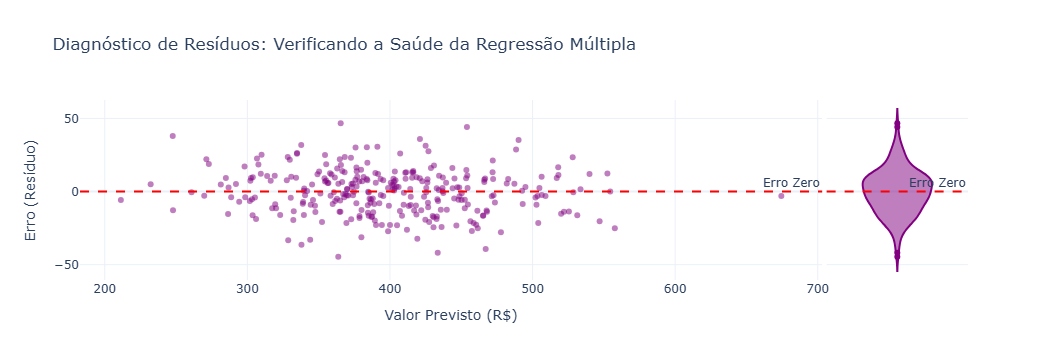

In [38]:


# 3. Criando o DataFrame de Resíduos para o Plotly
residuos_df = pd.DataFrame({
    'Valor_Real': y_test_rlm,
    'Previsao': y_pred_rlm,
    'Residuo': y_test_rlm - y_pred_rlm
})

# 4. Gráfico de Resíduos com Plotly Express
fig = px.scatter(
    residuos_df, 
    x='Previsao', 
    y='Residuo',
    marginal_y="violin", # Adiciona a distribuição do erro na lateral
    title="Diagnóstico de Resíduos: Verificando a Saúde da Regressão Múltipla",
    labels={'Previsao': 'Valor Previsto (R$)', 'Residuo': 'Erro (Resíduo)'},
    opacity=0.5,
    template="plotly_white",
    color_discrete_sequence=['purple']
)

# Adicionando a linha de referência no zero (Erro Zero)
fig.add_hline(y=0, line_dash="dash", line_color="red", annotation_text="Erro Zero")

fig.show()


A Linha Tracejada Vermelha: É o seu "norte". Se o ponto está na linha, o modelo acertou em cheio.

O Violino na Direita: O Plotly desenhou um gráfico de densidade (violin) no eixo Y. Se ele estiver "gordinho" perto do zero e afunilar nas pontas, seus erros seguem uma Distribuição Normal, o que é o padrão ouro da estatística.

Independência: Se você notar que os erros aumentam conforme o "Valor Previsto" aumenta (formato de leque ou funil), temos um problema de Heterocedasticidade. Isso significa que o modelo é bom para prever gastos baixos, mas se perde em gastos altos.

<h2 style="color : green">Conclusão </h2>
A RL Múltipla vence porque consegue mapear a complexidade do mundo real. Enquanto a RL Simples olha para o problema com apenas um olho, a Múltipla utiliza uma visão estereoscópica, cruzando informações para entregar uma previsão muito mais próxima da realidade.


<h2 style="color : green"> Referências Bibliograficas</h2>

https://www.ibm.com/br-pt/think/topics/machine-learning-types

https://www.mltut.com/machine-learning/

https://cloud.google.com/learn/what-is-machine-learning?hl=pt-BR